# 02 Decision Tree Churn Modelling

## Project Overview

This project develops an end-to-end binary classification solution for predicting customer churn in a retail banking context. The notebook covers business understanding, data validation, exploratory analysis, preprocessing, baseline development, hyperparameter optimization, model evaluation, interpretability, and artifact serialization.

The final model is designed to support a Streamlit application that accepts customer information and returns an estimated churn probability. The project emphasizes reproducibility, transparent decision logic, class-imbalance awareness, and production-ready artifact management.

## Project Metadata

- Project name: `02_DecisionTree_ChurnModelling`
- Dataset: `Churn_Modelling.csv`
- Target variable: `Exited`
- Primary algorithm: Decision Tree Classifier
- Optimization metric: ROC-AUC
- Validation method: 5-fold cross-validation
- Deployment framework: Streamlit
- Serialization library: joblib

In [2]:
from pathlib import Path
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print("Environment setup completed successfully.")

Environment setup completed successfully.


## Phase 1: Business Understanding and Problem Definition

Customer churn occurs when a customer terminates or substantially reduces their relationship with a service provider. In banking, telecommunications, subscription services, and digital platforms, churn directly affects recurring revenue, customer lifetime value, cross-selling opportunities, and forecasting reliability.

Retention programs are generally more targeted than acquisition campaigns because the organization already possesses behavioral, demographic, and account-level information about existing customers. A churn model can rank customers by risk, allowing retention teams to focus incentives, outreach, service recovery, and account reviews on the customers most likely to leave.

This is an imbalanced classification problem because retained customers usually outnumber churned customers. Accuracy can therefore be misleading. A model that predicts most customers as retained may achieve a high accuracy while failing to identify a useful share of actual churners.

The two error types have different business consequences:

- A false negative occurs when an actual churner is predicted as retained. This error may result in a missed retention opportunity and lost future revenue.
- A false positive occurs when a retained customer is predicted as a churner. This error may cause unnecessary outreach or incentive costs.

False negatives are often more costly, but the final operating threshold should reflect the organization's retention budget, intervention cost, and customer lifetime value.

A Decision Tree Classifier is selected because it can model nonlinear relationships and feature interactions without requiring linear assumptions. Its hierarchical rules are also interpretable, which supports business communication, model governance, and transparent decision review. Tree depth and node-size controls must be optimized because unrestricted trees can memorize training data and generalize poorly.

In [3]:
business_objective = {
    "problem_type": "Binary classification",
    "positive_class": "Exited = 1",
    "primary_validation_metric": "ROC-AUC",
    "supporting_metrics": ["Accuracy", "Precision", "Recall", "F1-score"],
    "business_priority": "Identify customers with elevated churn risk",
}

business_objective

{'problem_type': 'Binary classification',
 'positive_class': 'Exited = 1',
 'primary_validation_metric': 'ROC-AUC',
 'supporting_metrics': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
 'business_priority': 'Identify customers with elevated churn risk'}

## Phase 2: Environment Setup and Data Ingestion

Reliable ingestion is the first operational step in a machine learning workflow. The dataset location must not depend on a single working directory because a notebook may be executed from the repository root, from the `notebooks` directory, or from another managed environment.

The path-resolution logic below checks several valid project locations and raises a clear error when the dataset cannot be found. After loading, the workflow inspects dataset dimensions, sample records, data types, non-null counts, and memory usage. These checks confirm whether the file was read correctly and reveal structural issues before analysis begins.

In [4]:
candidate_data_paths = [
    Path("../data/raw/Churn_Modelling.csv"),
    Path("data/raw/Churn_Modelling.csv"),
    Path("Churn_Modelling.csv"),
    Path("/mnt/data/Churn_Modelling.csv"),
]

data_path = next((path for path in candidate_data_paths if path.exists()), None)

if data_path is None:
    checked_paths = "\n".join(str(path.resolve()) for path in candidate_data_paths)
    raise FileNotFoundError(
        "Churn_Modelling.csv was not found. Checked the following locations:\n"
        f"{checked_paths}"
    )

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path.resolve()}")
print(f"Dataset dimensions: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
display(df.head())

print("\nDataset information:")
df.info()

Dataset path: C:\Users\soham\Desktop\ahmed\NTI-ML\02_DecisionTree_ChurnModelling\data\raw\Churn_Modelling.csv
Dataset dimensions: 10,000 rows and 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,"101,348.880",1
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.860",1,0,1,"112,542.580",0
2,3,15619304,Onio,502,France,Female,42,8,"159,660.800",3,1,0,"113,931.570",1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,"93,826.630",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.820",1,1,1,"79,084.100",0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


## Phase 3: Data Quality Assessment and Cleaning

Data-quality assessment verifies whether each row and column is suitable for analytical use. Identifier fields such as row numbers, customer IDs, and surnames generally describe record administration rather than customer behavior. Retaining them may introduce noise, encourage memorization, or create unstable splits that do not generalize to new customers.

The cleaning procedure therefore:

- Checks duplicate records.
- Reviews missing values.
- Reviews categorical domains and numerical ranges.
- Removes non-predictive identifier columns when present.
- Confirms that the target variable is binary.
- Preserves the original dataset in a separate object for traceability.

In [5]:
raw_df = df.copy()

print(f"Exact duplicate rows before cleaning: {df.duplicated().sum():,}")

missing_summary_before = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percentage=lambda table: table["missing_count"] / len(df) * 100)
)

display(missing_summary_before)

identifier_columns = ["RowNumber", "CustomerId", "Surname"]
columns_to_drop = [column for column in identifier_columns if column in df.columns]

df = df.drop(columns=columns_to_drop).copy()

target_candidates = ["Exited", "Churn"]
target_column = next(
    (column for column in target_candidates if column in df.columns),
    None,
)

if target_column is None:
    raise KeyError(
        "The dataset must contain either an 'Exited' or 'Churn' target column."
    )

if df[target_column].isna().any():
    raise ValueError("The target column contains missing values.")

target_values = set(df[target_column].unique())
if not target_values.issubset({0, 1}):
    raise ValueError(
        f"The target column must be binary with values 0 and 1. Found: {target_values}"
    )

print(f"Dropped identifier columns: {columns_to_drop}")
print(f"Cleaned dataset dimensions: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
print("\nCleaned column schema:")
print(df.dtypes)

Exact duplicate rows before cleaning: 0


,missing_count,missing_percentage
RowNumber,0,0.000
CustomerId,0,0.000
Surname,0,0.000
CreditScore,0,0.000
Geography,0,0.000
Gender,0,0.000
Age,0,0.000
Tenure,0,0.000
Balance,0,0.000
NumOfProducts,0,0.000


Dropped identifier columns: ['RowNumber', 'CustomerId', 'Surname']
Cleaned dataset dimensions: 10,000 rows and 11 columns

Cleaned column schema:
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


## Phase 4: Exploratory Data Analysis

Exploratory data analysis examines the statistical behavior of the target and predictors before model training. Univariate analysis describes individual distributions, while bivariate analysis compares predictors with the churn outcome. This step helps identify class imbalance, unusual values, skewed variables, and potentially meaningful customer segments.

The analysis below includes:

- Absolute and percentage target distributions.
- Numerical summary statistics.
- Categorical frequency distributions.
- Churn rates across categorical variables.
- Churn-rate patterns across selected numerical variables.
- Correlation analysis for numerical features.

These observations are descriptive rather than causal. They support model design and business interpretation but do not prove that a feature causes churn.

In [6]:
target_counts = df[target_column].value_counts().sort_index()
target_percentages = (
    df[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})
target_distribution.index = target_distribution.index.map({
    0: "Retained",
    1: "Exited",
})

display(target_distribution)

imbalance_ratio = target_counts.get(0, 0) / max(target_counts.get(1, 0), 1)
print(f"Retained-to-exited class ratio: {imbalance_ratio:.2f}:1")

print("\nNumerical summary statistics:")
display(df.describe().T)

,count,percentage
Exited,,
Retained,7963,79.630
Exited,2037,20.370


Retained-to-exited class ratio: 3.91:1

Numerical summary statistics:


,count,mean,std,min,25%,50%,75%,max
CreditScore,"10,000.000",650.529,96.653,350.000,584.000,652.000,718.000,850.000
Age,"10,000.000",38.922,10.488,18.000,32.000,37.000,44.000,92.000
Tenure,"10,000.000",5.013,2.892,0.000,3.000,5.000,7.000,10.000
Balance,"10,000.000","76,485.889","62,397.405",0.000,0.000,"97,198.540","127,644.240","250,898.090"
NumOfProducts,"10,000.000",1.530,0.582,1.000,1.000,1.000,2.000,4.000
HasCrCard,"10,000.000",0.706,0.456,0.000,0.000,1.000,1.000,1.000
IsActiveMember,"10,000.000",0.515,0.500,0.000,0.000,1.000,1.000,1.000
EstimatedSalary,"10,000.000","100,090.240","57,510.493",11.580,"51,002.110","100,193.915","149,388.247","199,992.480"
Exited,"10,000.000",0.204,0.403,0.000,0.000,0.000,0.000,1.000


### Target Distribution Visualization

A visual comparison of retained and exited customers makes class imbalance easier to communicate. The positive class should remain large enough to support stratified splitting and cross-validation, while metric selection must still account for the unequal class frequencies.

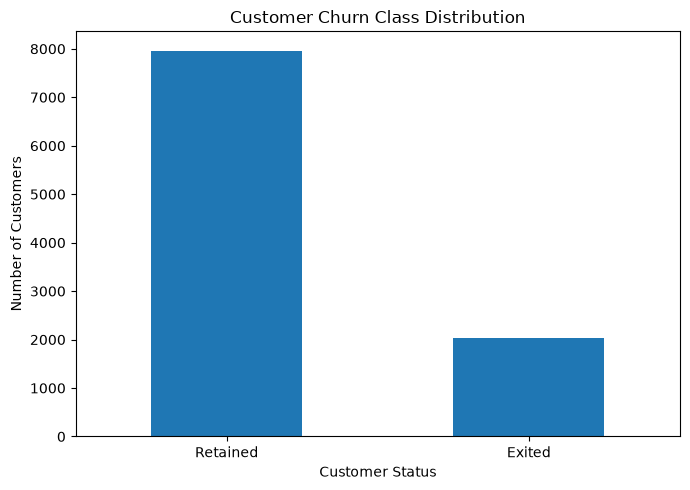

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
target_counts.rename(index={0: "Retained", 1: "Exited"}).plot(
    kind="bar",
    ax=ax,
)
ax.set_title("Customer Churn Class Distribution")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Categorical Feature Analysis

Categorical analysis evaluates whether churn rates vary across customer groups. Group-level churn rates can reveal useful segmentation patterns, although small groups should be interpreted carefully. The analysis reports both group size and average target value, where the average represents the observed churn rate.

In [8]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

for column in categorical_columns:
    print(f"\nFrequency distribution for {column}:")
    display(
        df[column]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percentage=lambda table: table["count"] / len(df) * 100)
    )

    print(f"Churn rate by {column}:")
    display(
        df.groupby(column, dropna=False)[target_column]
        .agg(customer_count="size", churn_rate="mean")
        .assign(churn_rate=lambda table: table["churn_rate"] * 100)
        .sort_values("churn_rate", ascending=False)
    )


Frequency distribution for Geography:


,count,percentage
Geography,,
France,5014,50.140
Germany,2509,25.090
Spain,2477,24.770


Churn rate by Geography:


,customer_count,churn_rate
Geography,,
Germany,2509,32.443
Spain,2477,16.673
France,5014,16.155



Frequency distribution for Gender:


,count,percentage
Gender,,
Male,5457,54.570
Female,4543,45.430


Churn rate by Gender:


,customer_count,churn_rate
Gender,,
Female,4543,25.072
Male,5457,16.456


### Numerical Feature Analysis by Churn Status

Comparing numerical feature averages across the two target classes provides a first view of potential separation. Large differences may indicate predictive value, but tree-based models can also capture nonlinear thresholds and interactions that are not visible from means alone.

In [9]:
numerical_columns = (
    df.select_dtypes(include=np.number)
    .columns
    .drop(target_column)
    .tolist()
)

numerical_comparison = (
    df.groupby(target_column)[numerical_columns]
    .mean()
    .T
    .rename(columns={0: "retained_mean", 1: "exited_mean"})
)

numerical_comparison["absolute_difference"] = (
    numerical_comparison["exited_mean"] -
    numerical_comparison["retained_mean"]
).abs()

display(
    numerical_comparison.sort_values(
        "absolute_difference",
        ascending=False,
    )
)

Exited,retained_mean,exited_mean,absolute_difference
Balance,"72,745.297","91,108.539","18,363.243"
EstimatedSalary,"99,738.392","101,465.678","1,727.286"
Age,37.408,44.838,7.430
CreditScore,651.853,645.351,6.502
IsActiveMember,0.555,0.361,0.194
Tenure,5.033,4.933,0.101
NumOfProducts,1.544,1.475,0.069
HasCrCard,0.707,0.699,0.008


### Numerical Correlation Analysis

Correlation measures linear association between numerical variables. Decision trees are not restricted to linear relationships and are less sensitive to multicollinearity than many parametric models. Nevertheless, the correlation matrix can reveal redundant variables and provide an initial indication of which features are linearly associated with churn.

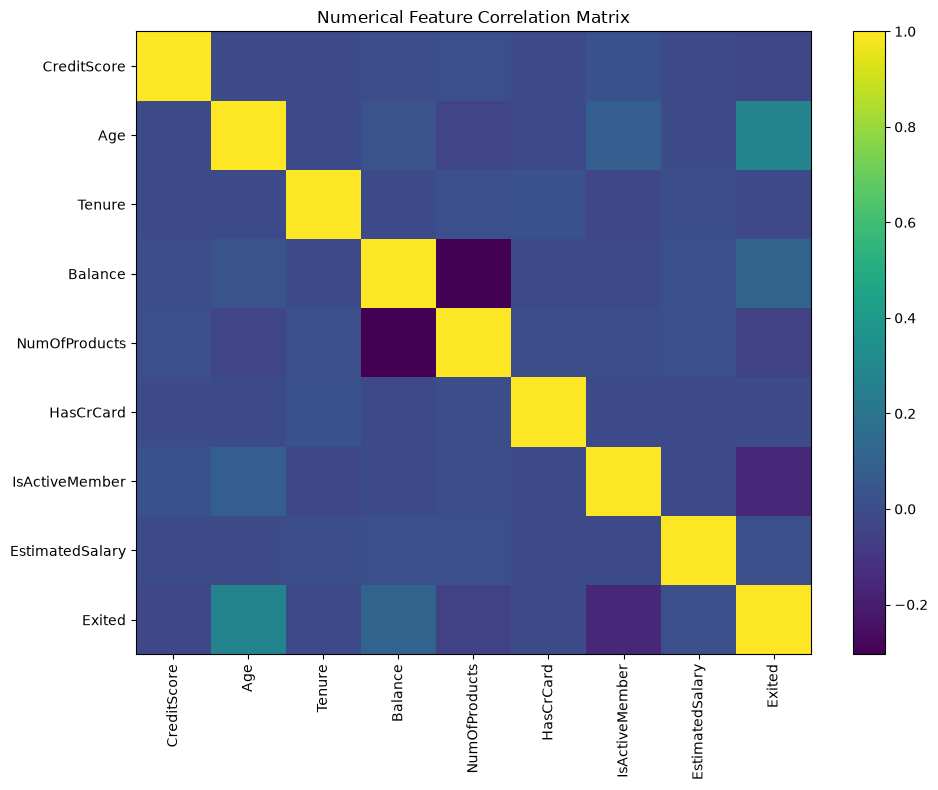

,correlation_with_target
Age,0.285
IsActiveMember,-0.156
Balance,0.119
NumOfProducts,-0.048
CreditScore,-0.027
Tenure,-0.014
EstimatedSalary,0.012
HasCrCard,-0.007


In [10]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation_matrix, aspect="auto")
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Numerical Feature Correlation Matrix")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

display(
    correlation_matrix[target_column]
    .drop(target_column)
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation_with_target")
)

## Phase 5: Data Preprocessing and Feature Engineering

Machine learning estimators require a numerical feature matrix with a fixed column order. The target is separated from the predictors, and categorical features are transformed using one-hot encoding. The first category is dropped to avoid a redundant dummy column.

The complete ordered feature list is stored because production inference must reproduce exactly the same feature schema used during training. A single incoming customer may not contain every dummy category after encoding, so the deployment application will reindex its encoded record to this saved schema.

The dataset contains no missing values in its standard form. A defensive validation step is still included to prevent silent training errors if the file is replaced with a modified version.

In [11]:
X = df.drop(columns=[target_column]).copy()
y = df[target_column].astype(int).copy()

if X.isna().any().any():
    columns_with_missing_values = X.columns[X.isna().any()].tolist()
    raise ValueError(
        "Missing values were detected in the feature matrix. "
        f"Affected columns: {columns_with_missing_values}"
    )

X_encoded = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int,
)

feature_columns = X_encoded.columns.tolist()

print(f"Encoded feature matrix dimensions: {X_encoded.shape}")
print(f"Number of model features: {len(feature_columns)}")
print(f"Feature columns: {feature_columns}")
display(X_encoded.head())

Encoded feature matrix dimensions: (10000, 11)
Number of model features: 11
Feature columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.000,1,1,1,"101,348.880",0,0,0
1,608,41,1,"83,807.860",1,0,1,"112,542.580",0,1,0
2,502,42,8,"159,660.800",3,1,0,"113,931.570",0,0,0
3,699,39,1,0.000,2,0,0,"93,826.630",0,0,0
4,850,43,2,"125,510.820",1,1,1,"79,084.100",0,1,0


## Phase 6: Baseline Model Development and Train-Test Split

The holdout test set estimates generalization performance on observations that are not used during model fitting or hyperparameter selection. Stratification preserves the target proportions in both subsets, which is especially important for imbalanced classification.

A StandardScaler is fitted only on the training data and then applied to both training and test data. Decision trees do not mathematically require feature scaling because their splits depend on ordered thresholds rather than distance or gradient magnitudes. Scaling is retained here to satisfy the specified deployment architecture and to demonstrate leakage-safe preprocessing. The scaler must never be fitted on the test set.

The baseline model uses default Decision Tree settings. Its purpose is to establish a reference point before tree complexity and class weighting are optimized.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_dt_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
)

baseline_dt_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_dt_model.predict(X_test_scaled)
baseline_probabilities = baseline_dt_model.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, baseline_predictions),
    "roc_auc": roc_auc_score(y_test, baseline_probabilities),
    "precision": precision_score(y_test, baseline_predictions, zero_division=0),
    "recall": recall_score(y_test, baseline_predictions, zero_division=0),
    "f1_score": f1_score(y_test, baseline_predictions, zero_division=0),
})

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")
print("\nBaseline Decision Tree metrics:")
display(baseline_metrics.to_frame("score"))

Training observations: 8,000
Testing observations: 2,000

Baseline Decision Tree metrics:


,score
accuracy,0.782
roc_auc,0.681
precision,0.468
recall,0.511
f1_score,0.489


## Phase 7: Hyperparameter Tuning

An unrestricted Decision Tree can continue splitting until it creates highly specific terminal nodes. This often produces low training error but unstable test performance. Hyperparameter tuning controls tree growth and improves the bias-variance balance.

The selected parameters regulate complexity:

- `max_depth` limits the number of hierarchical decision levels.
- `min_samples_split` requires a minimum number of observations before a node can divide.
- `min_samples_leaf` prevents terminal nodes from representing extremely small customer groups.
- `class_weight='balanced'` increases the relative loss assigned to errors on the minority class according to class frequency.

GridSearchCV evaluates every candidate configuration with 5-fold stratified cross-validation. ROC-AUC is used because it evaluates probability ranking across thresholds and is more informative than accuracy when class proportions are unequal.

In [13]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": ["balanced"],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train_scaled, y_train)

best_dt_model = grid_search.best_estimator_

print("Best Decision Tree estimator:")
print(best_dt_model)
print("\nOptimal hyperparameters:")
print(grid_search.best_params_)
print(f"\nBest cross-validation ROC-AUC: {grid_search.best_score_:.4f}")

Best Decision Tree estimator:
DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=10, random_state=42)

Optimal hyperparameters:
{'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best cross-validation ROC-AUC: 0.8380


### Cross-Validation Results Review

The best score alone does not show how model complexity affects generalization. The following table ranks candidate configurations by validation ROC-AUC and compares their average training and validation scores. A large training-validation gap may indicate overfitting.

In [14]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_summary = cv_results[
    [
        "rank_test_score",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_class_weight",
    ]
].sort_values("rank_test_score")

display(cv_summary.head(10))

,rank_test_score,mean_train_score,std_train_score,mean_test_score,std_test_score,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_class_weight
60,1,0.867,0.004,0.838,0.017,6,2,10,balanced
61,1,0.867,0.004,0.838,0.017,6,5,10,balanced
62,1,0.867,0.004,0.838,0.017,6,10,10,balanced
63,1,0.867,0.004,0.838,0.017,6,20,10,balanced
59,5,0.867,0.004,0.835,0.017,6,20,5,balanced
55,6,0.868,0.004,0.834,0.017,6,20,2,balanced
45,7,0.848,0.003,0.834,0.014,5,5,10,balanced
44,7,0.848,0.003,0.834,0.014,5,2,10,balanced
47,7,0.848,0.003,0.834,0.014,5,20,10,balanced
46,7,0.848,0.003,0.834,0.014,5,10,10,balanced


## Phase 8: Optimized Model Evaluation

Accuracy alone can conceal poor minority-class performance. The optimized model is therefore evaluated with complementary metrics:

- ROC-AUC measures the model's ability to rank churners above retained customers across possible thresholds.
- Precision measures the proportion of predicted churners who actually churned.
- Recall measures the proportion of actual churners correctly detected.
- F1-score balances precision and recall.
- The confusion matrix displays the counts of true negatives, false positives, false negatives, and true positives.

The default classification threshold is 0.50. This threshold is suitable for model comparison but may not be the final business threshold. Production threshold selection should incorporate retention cost and expected customer value.

In [15]:
y_pred = best_dt_model.predict(X_test_scaled)
y_pred_proba = best_dt_model.predict_proba(X_test_scaled)[:, 1]

optimized_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_pred_proba),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0),
})

model_comparison = pd.DataFrame({
    "baseline_decision_tree": baseline_metrics,
    "optimized_decision_tree": optimized_metrics,
})

display(model_comparison)

print("Optimized Decision Tree classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Retained", "Exited"],
    digits=4,
))

,baseline_decision_tree,optimized_decision_tree
accuracy,0.782,0.761
roc_auc,0.681,0.840
precision,0.468,0.450
recall,0.511,0.769
f1_score,0.489,0.568


Optimized Decision Tree classification report:
              precision    recall  f1-score   support

    Retained     0.9279    0.7596    0.8353      1593
      Exited     0.4497    0.7690    0.5675       407

    accuracy                         0.7615      2000
   macro avg     0.6888    0.7643    0.7014      2000
weighted avg     0.8306    0.7615    0.7808      2000



### Confusion Matrix

The confusion matrix shows the exact distribution of classification outcomes. In a churn setting, false negatives deserve particular attention because they represent customers who actually exited but were not flagged for intervention.

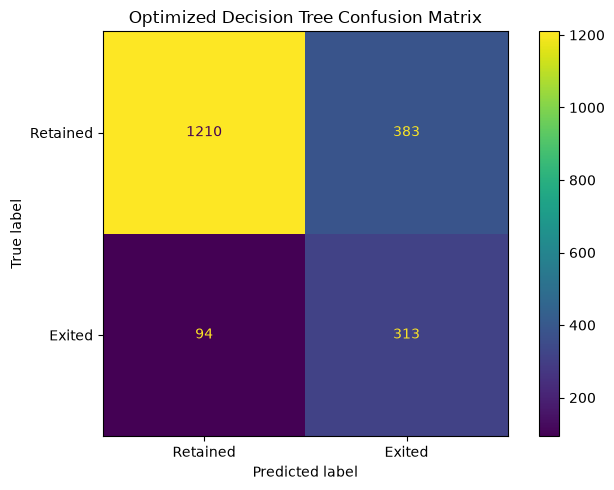

True negatives: 1,210
False positives: 383
False negatives: 94
True positives: 313


In [16]:
confusion = confusion_matrix(y_test, y_pred)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Retained", "Exited"],
)

fig, ax = plt.subplots(figsize=(7, 5))
display_matrix.plot(ax=ax, values_format="d")
ax.set_title("Optimized Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion.ravel()
print(f"True negatives: {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives: {tp:,}")

### ROC Curve

The ROC curve plots the true-positive rate against the false-positive rate across classification thresholds. A model with stronger ranking performance produces a curve closer to the upper-left region. The area under this curve summarizes discrimination performance independently of a single threshold.

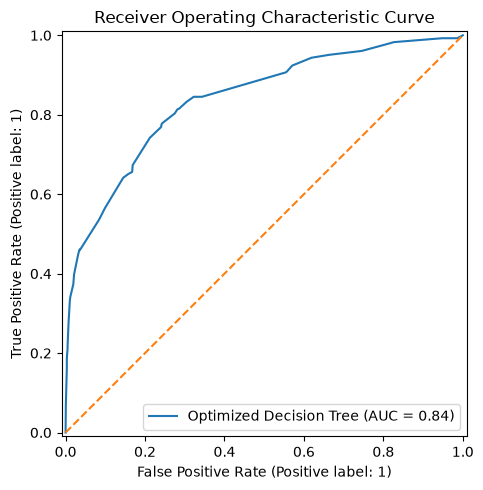

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba,
    name="Optimized Decision Tree",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Receiver Operating Characteristic Curve")
plt.tight_layout()
plt.show()

### Classification Threshold Analysis

The probability threshold controls the trade-off between precision and recall. Lower thresholds generally identify more churners and increase recall, but they may also produce more false positives. The following table compares several thresholds so that model behavior can be aligned with retention capacity and intervention cost.

In [18]:
threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):
    threshold_predictions = (y_pred_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "predicted_churners": int(threshold_predictions.sum()),
    })

threshold_table = pd.DataFrame(threshold_results)
display(threshold_table)

,threshold,precision,recall,f1_score,predicted_churners
0,0.200,0.293,0.924,0.444,1285
1,0.250,0.294,0.909,0.444,1258
2,0.300,0.395,0.845,0.538,871
3,0.350,0.421,0.816,0.556,788
4,0.400,0.450,0.779,0.570,705
5,0.450,0.451,0.776,0.570,701
6,0.500,0.450,0.769,0.568,696
7,0.550,0.450,0.769,0.568,696
8,0.600,0.500,0.656,0.567,534
9,0.650,0.593,0.565,0.579,388


## Phase 9: Model Interpretability

Decision Trees provide global interpretability through feature importance and hierarchical split rules. Feature importance estimates the total impurity reduction attributed to each feature across the tree. It indicates which variables the model used most heavily, but it does not prove causal influence.

A limited tree visualization is also generated. Because a fully expanded tree may be difficult to read, the displayed depth is restricted while the complete trained model remains unchanged.

,feature,importance
0,Age,0.434
1,NumOfProducts,0.313
2,Balance,0.122
3,IsActiveMember,0.065
4,Geography_Germany,0.042
5,Gender_Male,0.009
6,EstimatedSalary,0.005
7,CreditScore,0.004
8,Tenure,0.004
9,Geography_Spain,0.002


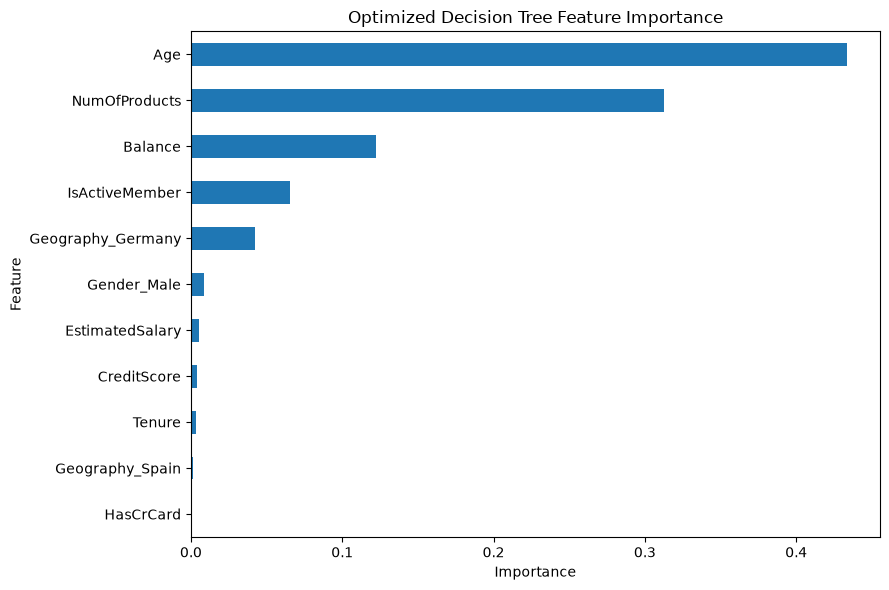

In [19]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": best_dt_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

fig, ax = plt.subplots(figsize=(9, 6))
feature_importance.sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    ax=ax,
)
ax.set_title("Optimized Decision Tree Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Decision Tree Structure

The tree visualization displays the first three levels of the optimized model. Each node shows the selected feature threshold, impurity, sample count, and class distribution. This representation helps analysts explain how major customer segments are separated by the model.

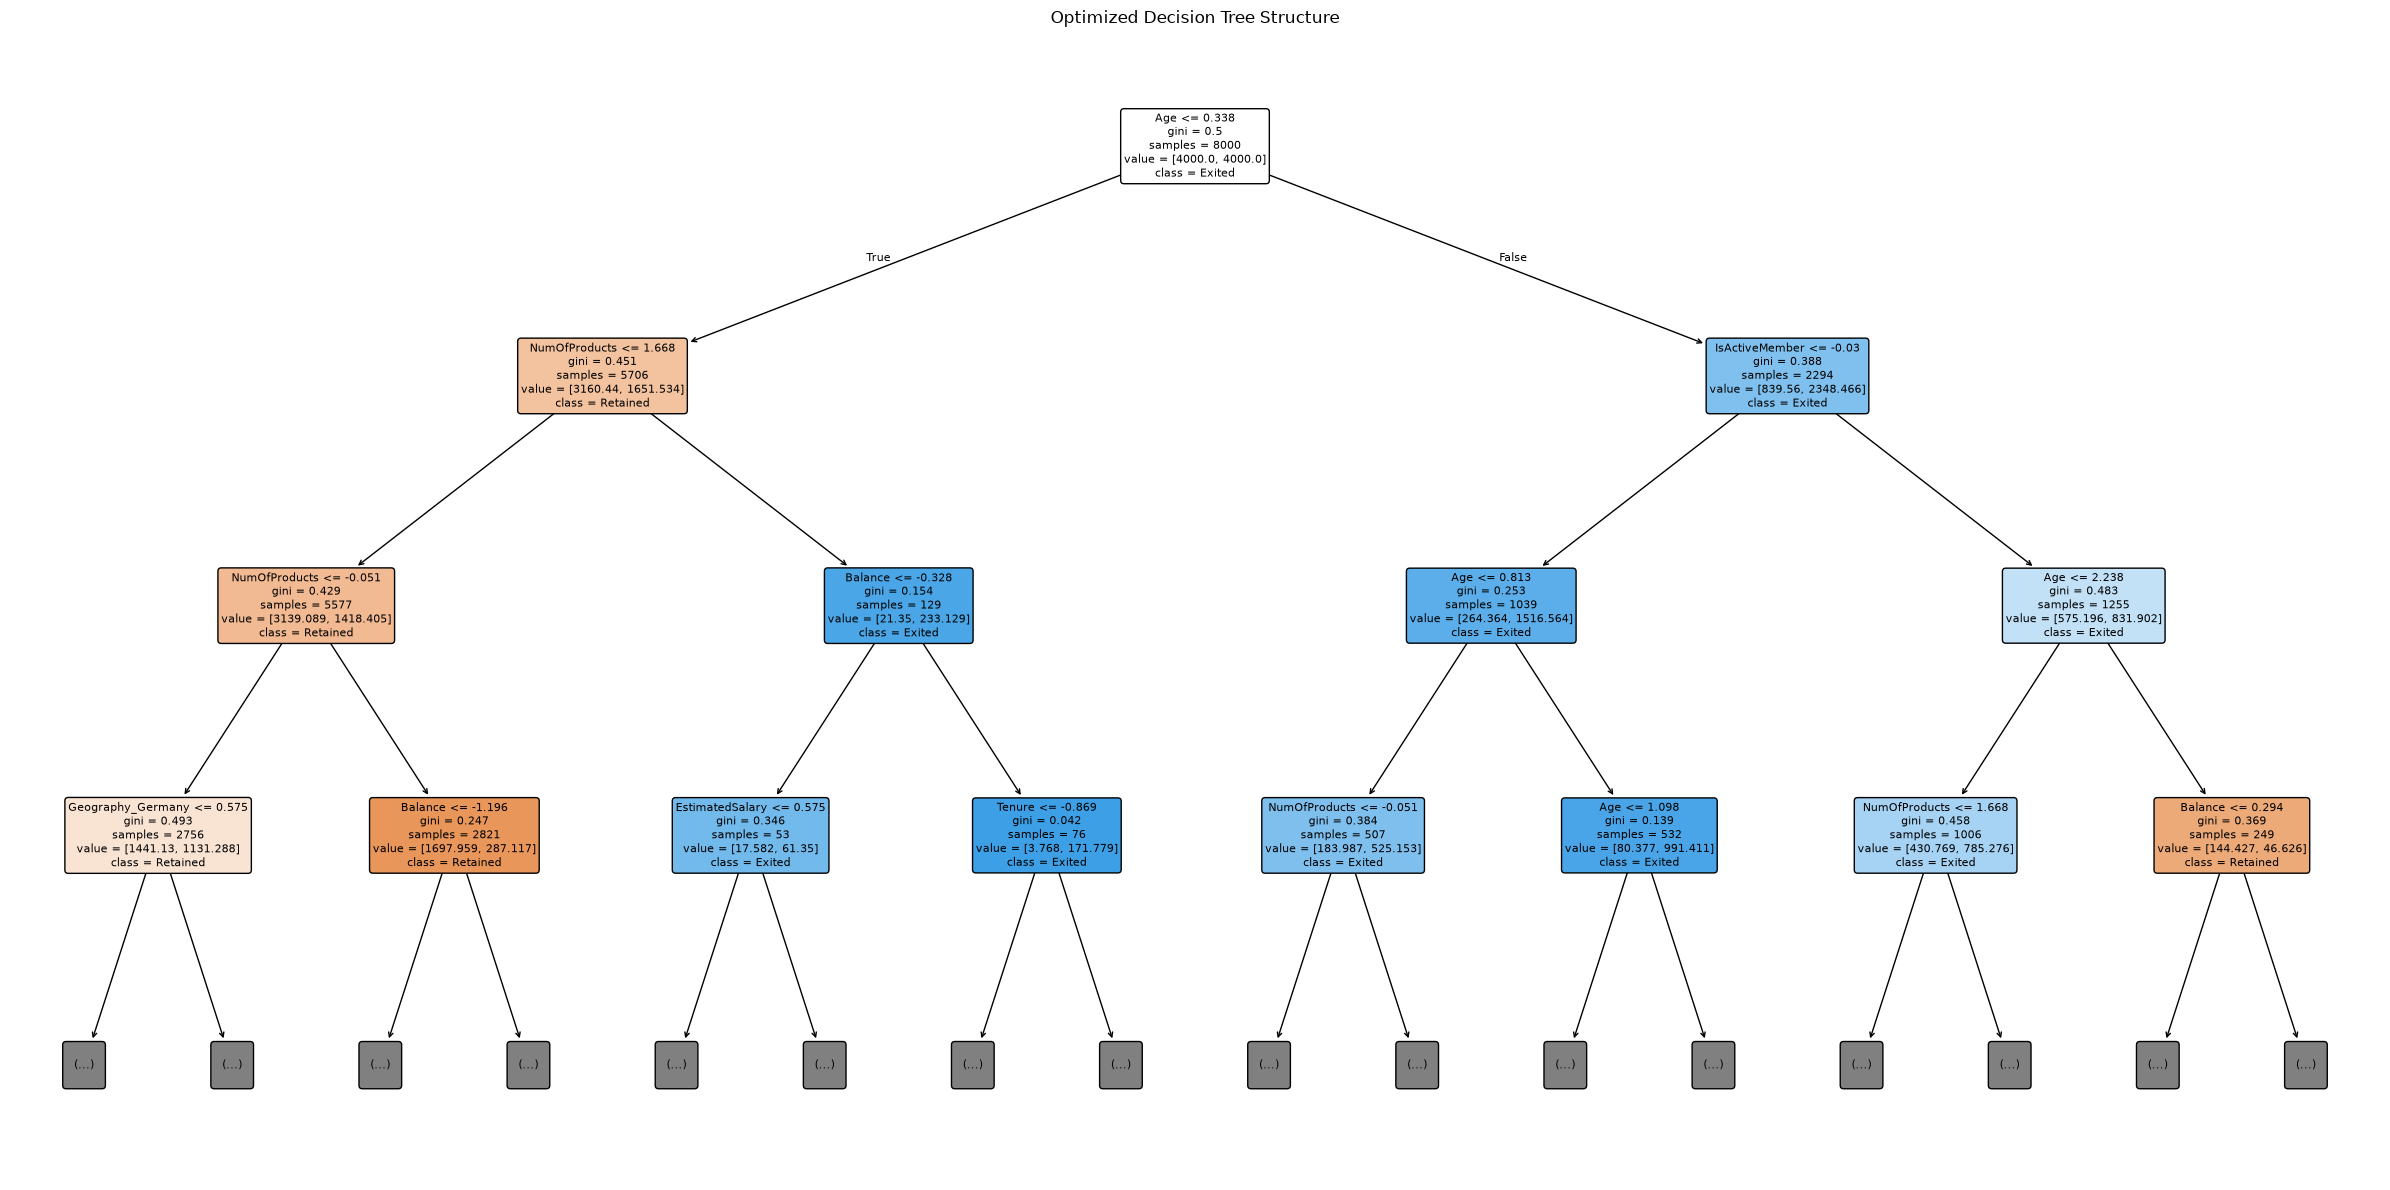

In [20]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    best_dt_model,
    feature_names=feature_columns,
    class_names=["Retained", "Exited"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title("Optimized Decision Tree Structure")
plt.tight_layout()
plt.show()

## Phase 10: Model Serialization

Serialization separates model training from production inference. The Streamlit application should load validated artifacts rather than retrain the model for every user request.

Three artifacts are required:

- The optimized Decision Tree model.
- The fitted StandardScaler.
- The exact ordered list of encoded feature columns.

The path logic supports execution from either the repository root or the `notebooks` directory. The target directory is created automatically when necessary.

In [21]:
if Path("../models").parent.exists() and Path.cwd().name == "notebooks":
    models_path = Path("../models")
else:
    models_path = Path("models")

models_path.mkdir(parents=True, exist_ok=True)

model_artifact_path = models_path / "decision_tree_model.joblib"
scaler_artifact_path = models_path / "standard_scaler.joblib"
features_artifact_path = models_path / "feature_columns.joblib"

joblib.dump(best_dt_model, model_artifact_path)
joblib.dump(scaler, scaler_artifact_path)
joblib.dump(feature_columns, features_artifact_path)

print(f"Decision Tree model saved to: {model_artifact_path.resolve()}")
print(f"StandardScaler saved to: {scaler_artifact_path.resolve()}")
print(f"Feature columns saved to: {features_artifact_path.resolve()}")

Decision Tree model saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\02_DecisionTree_ChurnModelling\models\decision_tree_model.joblib
StandardScaler saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\02_DecisionTree_ChurnModelling\models\standard_scaler.joblib
Feature columns saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\02_DecisionTree_ChurnModelling\models\feature_columns.joblib


## Phase 11: Artifact Validation

A production artifact should be reloaded and tested before deployment. This validation confirms that all files exist, the feature order is preserved, and the reloaded model reproduces the same predictions generated before serialization.

In [22]:
reloaded_model = joblib.load(model_artifact_path)
reloaded_scaler = joblib.load(scaler_artifact_path)
reloaded_feature_columns = joblib.load(features_artifact_path)

if reloaded_feature_columns != feature_columns:
    raise ValueError("Reloaded feature columns do not match the training schema.")

reloaded_predictions = reloaded_model.predict(
    reloaded_scaler.transform(X_test)
)

if not np.array_equal(reloaded_predictions, y_pred):
    raise ValueError(
        "Reloaded artifacts do not reproduce the original model predictions."
    )

print("Artifact validation completed successfully.")
print("The serialized model reproduces the original test predictions.")

Artifact validation completed successfully.
The serialized model reproduces the original test predictions.


## Final Conclusions

The project produced a tuned and interpretable Decision Tree classifier for customer churn prediction. The workflow addressed identifier removal, class imbalance, leakage-safe scaling, stratified splitting, cross-validated hyperparameter tuning, multi-metric evaluation, threshold analysis, model interpretation, and production artifact validation.

The optimized model should be assessed against business costs before deployment. In particular, the operating threshold should be selected according to the expected value of retaining a true churner, the cost of contacting a retained customer, and the available retention capacity.

The serialized artifacts are ready for use by the accompanying Streamlit application. Future development may compare the Decision Tree with ensemble models such as Random Forest and XGBoost, add probability calibration, incorporate automated data validation, and implement monitoring for data drift and performance degradation.